In [1]:
# Read all JSON/NDJSON files under outputs, merge into a DataFrame and plot key metrics
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
from IPython.display import clear_output

def plot_train_metric_from_files(data_path_lis):
    data_lis = []
    dataset_labels = [Path(p).parent.name or Path(p).stem for p in data_path_lis]

    #print('start loading data from list')
    for data_path in data_path_lis:
        data = pd.read_json(data_path, lines=True)
        data_lis.append(data)

    if not data_lis:
        raise ValueError('No data loaded. Please check the provided paths.')

    #print(data_lis[0].keys())

    plot_start = 100  # skip the first point which is usually very high loss
    plot_end = -1
    end_slice = plot_end if plot_end != -1 else None

    metrics = ['lr', 'total_loss', 'dino_local_crops_loss', 'dino_global_crops_loss', 'koleo_loss', 'ibot_loss']
    metrics = list(data_lis[0].keys())[1:]
    n = len(metrics)
    #print('start plotting')
    import math
    rows = math.ceil(n / 3)
    fig, axes = plt.subplots(nrows=rows, ncols=3, figsize=(15, 3 * rows), sharex=True, constrained_layout=True)
    axes = axes.flatten()

    for ax, metric in zip(axes, metrics):
        legend_handles = []
        legend_labels = []
        for i, d in enumerate(data_lis):
            if metric in d.columns:
                try:
                    label = dataset_labels[i]
                    x_vals = d['iteration'][plot_start:end_slice]
                    y_vals = d[metric][plot_start:end_slice]
                    (line,) = ax.plot(
                        x_vals,
                        y_vals,
                        marker='o',
                        markersize=2,
                        linewidth=1,
                        label=label,
                        alpha=0.4,
                    )
                    legend_handles.append(line)
                    legend_labels.append(label)
                except Exception:
                    continue
                    # print(f"Error plotting {metric}: {e}")
        ax.set_ylabel(metric)
        if legend_handles:
            order = {label: idx for idx, label in enumerate(dataset_labels)}
            sorted_items = sorted(
                zip(legend_handles, legend_labels),
                key=lambda item: order.get(item[1], float('inf')),
            )
            handles, labels = zip(*sorted_items)
            ax.legend(handles, labels)
        else:
            ax.legend()
        ax.grid(True)

    axes[-1].set_xlabel('Iteration')
    plt.show()

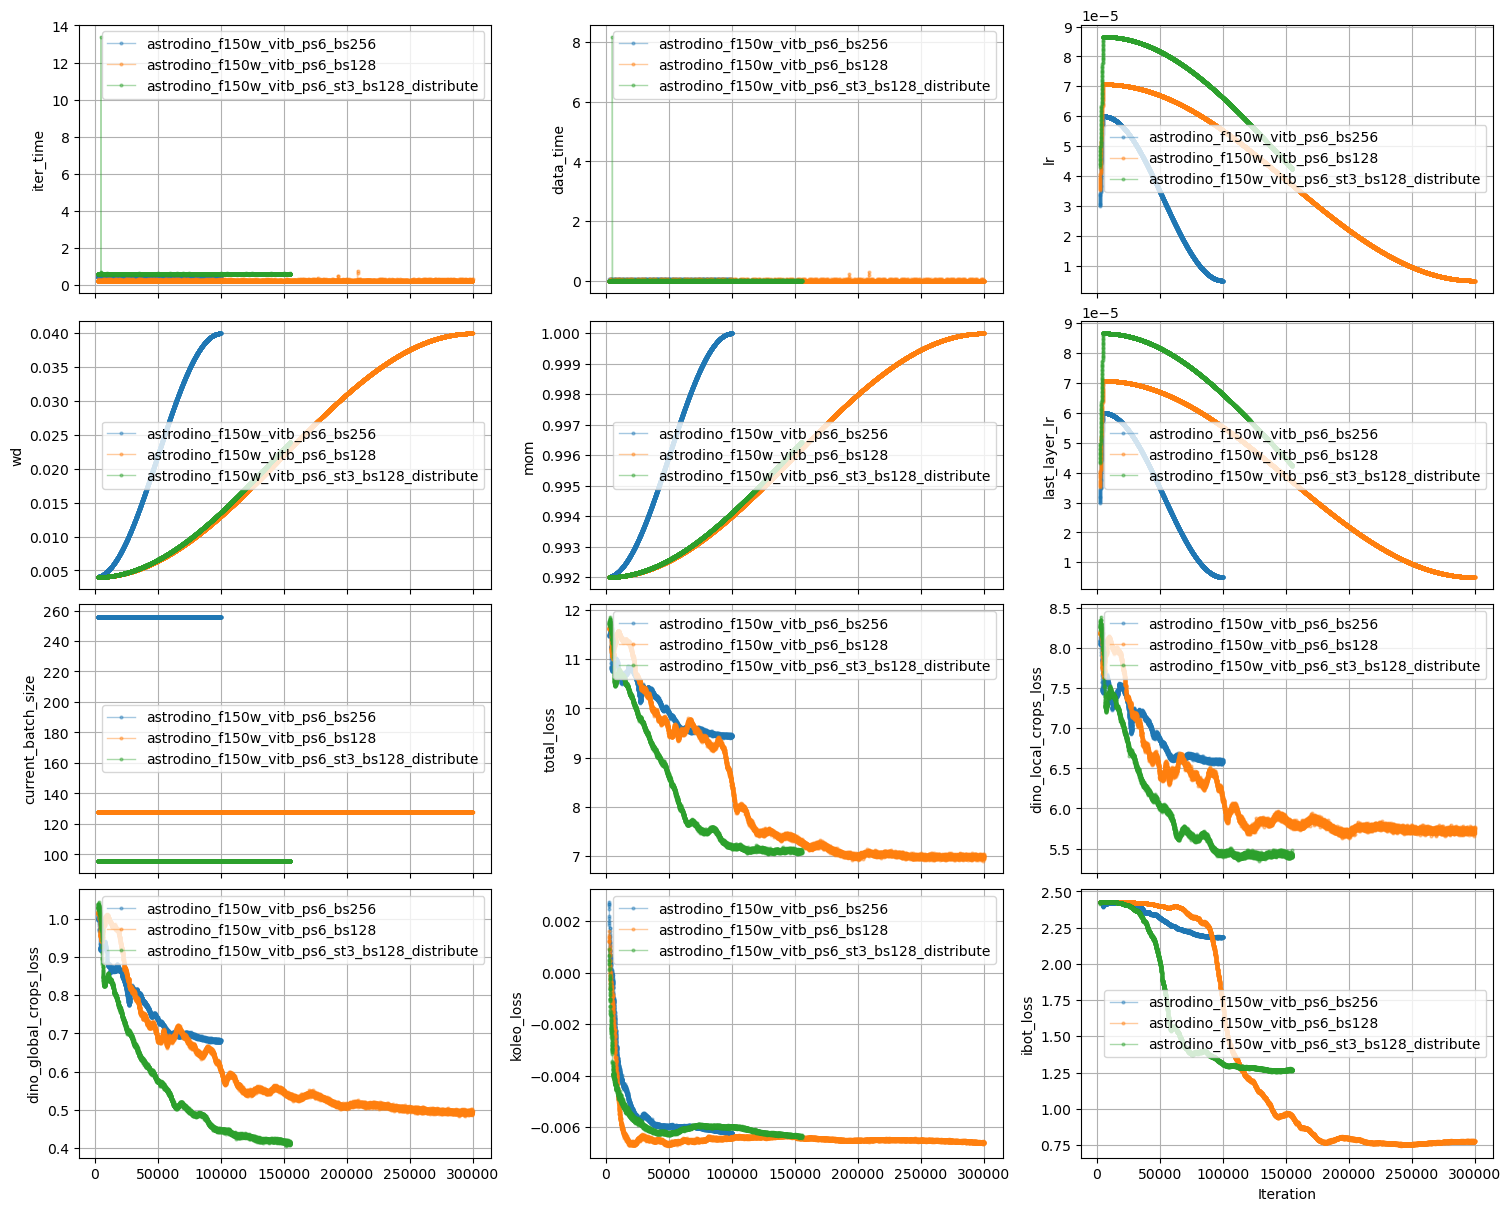

In [10]:
data_list =[ 
            '/home/yacheng/ssl_outthere/encoder_image/astrodino/model/astrodino_f150w_vitb_ps6_bs256/training_metrics.json',
            '/home/yacheng/ssl_outthere/encoder_image/astrodino/model/astrodino_f150w_vitb_ps6_bs128/training_metrics.json',
            '/home/yacheng/ssl_outthere/encoder_image/astrodino/model/astrodino_f150w_vitb_ps6_st3_bs128_distribute/training_metrics.json'
]
plot_train_metric_from_files(data_list)

In [44]:
from tqdm.auto import tqdm

plot_time = (4 * 3600)
plot_step = (2)
for plot in tqdm(range(int(plot_time/plot_step))):
    print(f'{plot} th plot')
    clear_output(wait=True)
    plot_train_metric_from_files(data_list)
    time.sleep(plot_step)

KeyboardInterrupt: 